In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append(r'C:\Users\MJ\Desktop')
# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'D:/COVID19'
model_algo="resnet18"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [7]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_0.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.125203524690049, 0.9577483801295896)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.16302692797365, 0.9449562957713206)

In [10]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

COVID              0.992233
Lung_Opacity       0.905435
Normal             0.970526
Viral Pneumonia    0.998935
dtype: float64

In [11]:
targetF=[x  for x in each_accu.nsmallest(2).index.map(trainset.dataset.classess)]
targetF

[1, 2]

In [12]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(11302, 3514)

In [13]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(3280, 953)

In [14]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [15]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [16]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.03711722953849498,train_accu=0.9854886609071274
Epoch=0,valid_loss=0.057301069792873145,valid_accu=0.9775572879754312
0
Epoch=1,train_loss=0.01503202533526658,train_accu=0.9944654427645788
Epoch=1,valid_loss=0.035370308039971744,valid_accu=0.988896763524687
0
Epoch=2,train_loss=0.0037101997024196185,train_accu=0.9989875809935205
Epoch=2,valid_loss=0.02195372804127371,valid_accu=0.9933853059296007
0
Epoch=3,train_loss=0.013378395462682586,train_accu=0.9948704103671706
Epoch=3,valid_loss=0.04159970548479804,valid_accu=0.9851169383416017
Epoch=4,train_loss=0.010609386148876056,train_accu=0.996085313174946
Epoch=4,valid_loss=0.04537273663238493,valid_accu=0.986061894637373
Epoch=5,train_loss=0.0016279254415853628,train_accu=0.9995275377969762
Epoch=5,valid_loss=0.021319744674239638,valid_accu=0.9926765887077723
Epoch=6,train_loss=0.09256104007154509,train_accu=0.9713147948164147
Epoch=6,valid_loss=0.1460484123164262,valid_accu=0.9650366170564612
4 Early stopping!


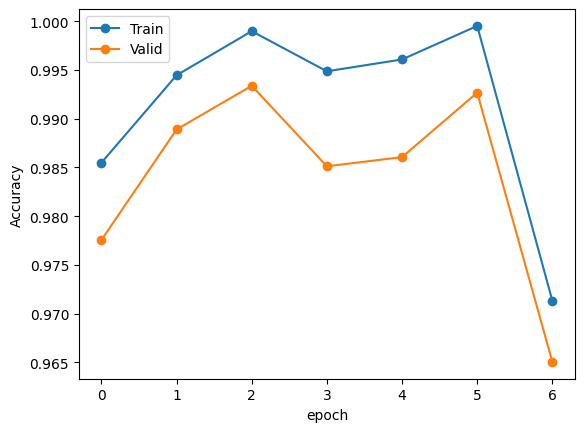

In [17]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.00827811982211809,train_accu=0.9985771200910644
Epoch=0,valid_loss=0.018110414270159143,valid_accu=0.9958027282266527
0
Epoch=1,train_loss=0.0017639282301961995,train_accu=1.0
Epoch=1,valid_loss=0.014983254832612373,valid_accu=0.9979013641133263
0
Epoch=2,train_loss=0.0033792608223302107,train_accu=0.9994308480364257
Epoch=2,valid_loss=0.018708453731609415,valid_accu=0.9958027282266527
Epoch=3,train_loss=0.012319926077812193,train_accu=0.9951622083096187
Epoch=3,valid_loss=0.016888569342705412,valid_accu=0.9968520461699895
Epoch=4,train_loss=0.0006579339806908528,train_accu=1.0
Epoch=4,valid_loss=0.019375461629303103,valid_accu=0.9979013641133263
Epoch=5,train_loss=0.0003928904420699909,train_accu=1.0
Epoch=5,valid_loss=0.014864567260341943,valid_accu=0.9979013641133263
4 Early stopping!


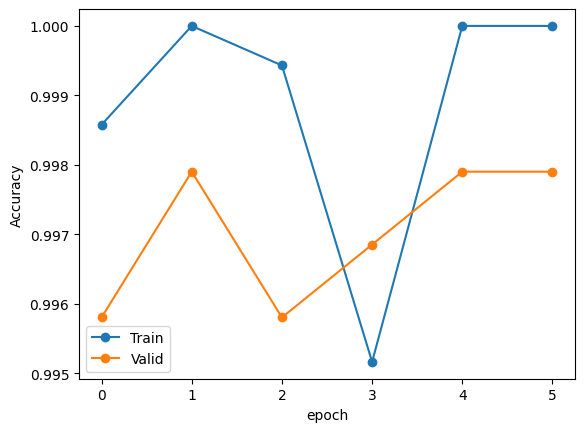

In [18]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.13036968818630207,train_accu=0.9498318881613874
Epoch=0,valid_loss=0.16343601818491774,valid_accu=0.9399390243902439
0
Epoch=1,train_loss=0.10090632706490307,train_accu=0.9628384356751017
Epoch=1,valid_loss=0.17789422629809962,valid_accu=0.9371951219512196
Epoch=2,train_loss=0.036827810126460775,train_accu=0.9873473721465228
Epoch=2,valid_loss=0.15891260507221266,valid_accu=0.9548780487804878
0
Epoch=3,train_loss=0.02274618224367164,train_accu=0.9930100867103168
Epoch=3,valid_loss=0.1743392923869556,valid_accu=0.9570121951219512
0
Epoch=4,train_loss=0.01380884678711496,train_accu=0.9966377632277473
Epoch=4,valid_loss=0.18834680431499715,valid_accu=0.95
Epoch=5,train_loss=0.026551822340758136,train_accu=0.9920368076446646
Epoch=5,valid_loss=0.19746883129019563,valid_accu=0.9451219512195121
Epoch=6,train_loss=0.009159143221519691,train_accu=0.9970801628030437
Epoch=6,valid_loss=0.20950637483378737,valid_accu=0.9557926829268293
Epoch=7,train_loss=0.004350991889756502,

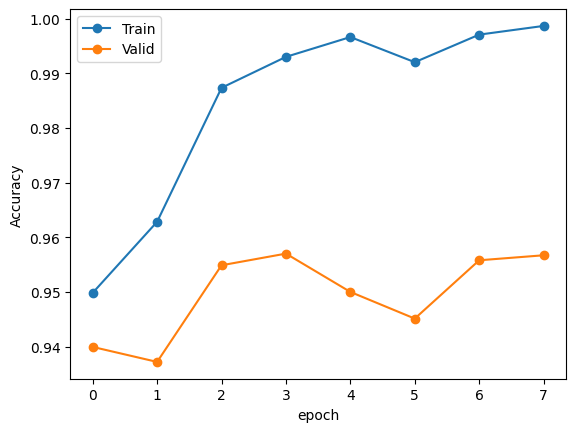

In [19]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [20]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.0037101997024196185, 0.9989875809935205)

In [21]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.02195372804127371, 0.9933853059296007)

In [22]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.0017639282403336747, 1.0)

In [23]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.022746182347829463, 0.9930100867103168)

In [24]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.014983253784630163, 0.9979013641133263)

In [25]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.17433929068899554, 0.9570121951219512)

In [26]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.01776969378344417, 0.9946679265658748, 11302)

In [27]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.1384624857065516, 0.9662178124261753, 3280)

In [28]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.02682664391728516, 0.9936555075593952, 11313, 3503)

In [29]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.19260806919020765, 0.9600755965036617, 3294, 939)

In [30]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [31]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.125204,0.957748,0.163027,0.944956
1,Model_Decision,0.003710,0.998988,0.003710,0.993385
2,Model_T,0.001764,1.000000,0.014983,0.997901
3,Model_F,0.022746,0.993010,0.174339,0.957012
4,Total_Model,0.026827,0.993656,0.192608,0.960076
5,Total_Model_without_decision,0.017770,0.994668,0.138462,0.966218


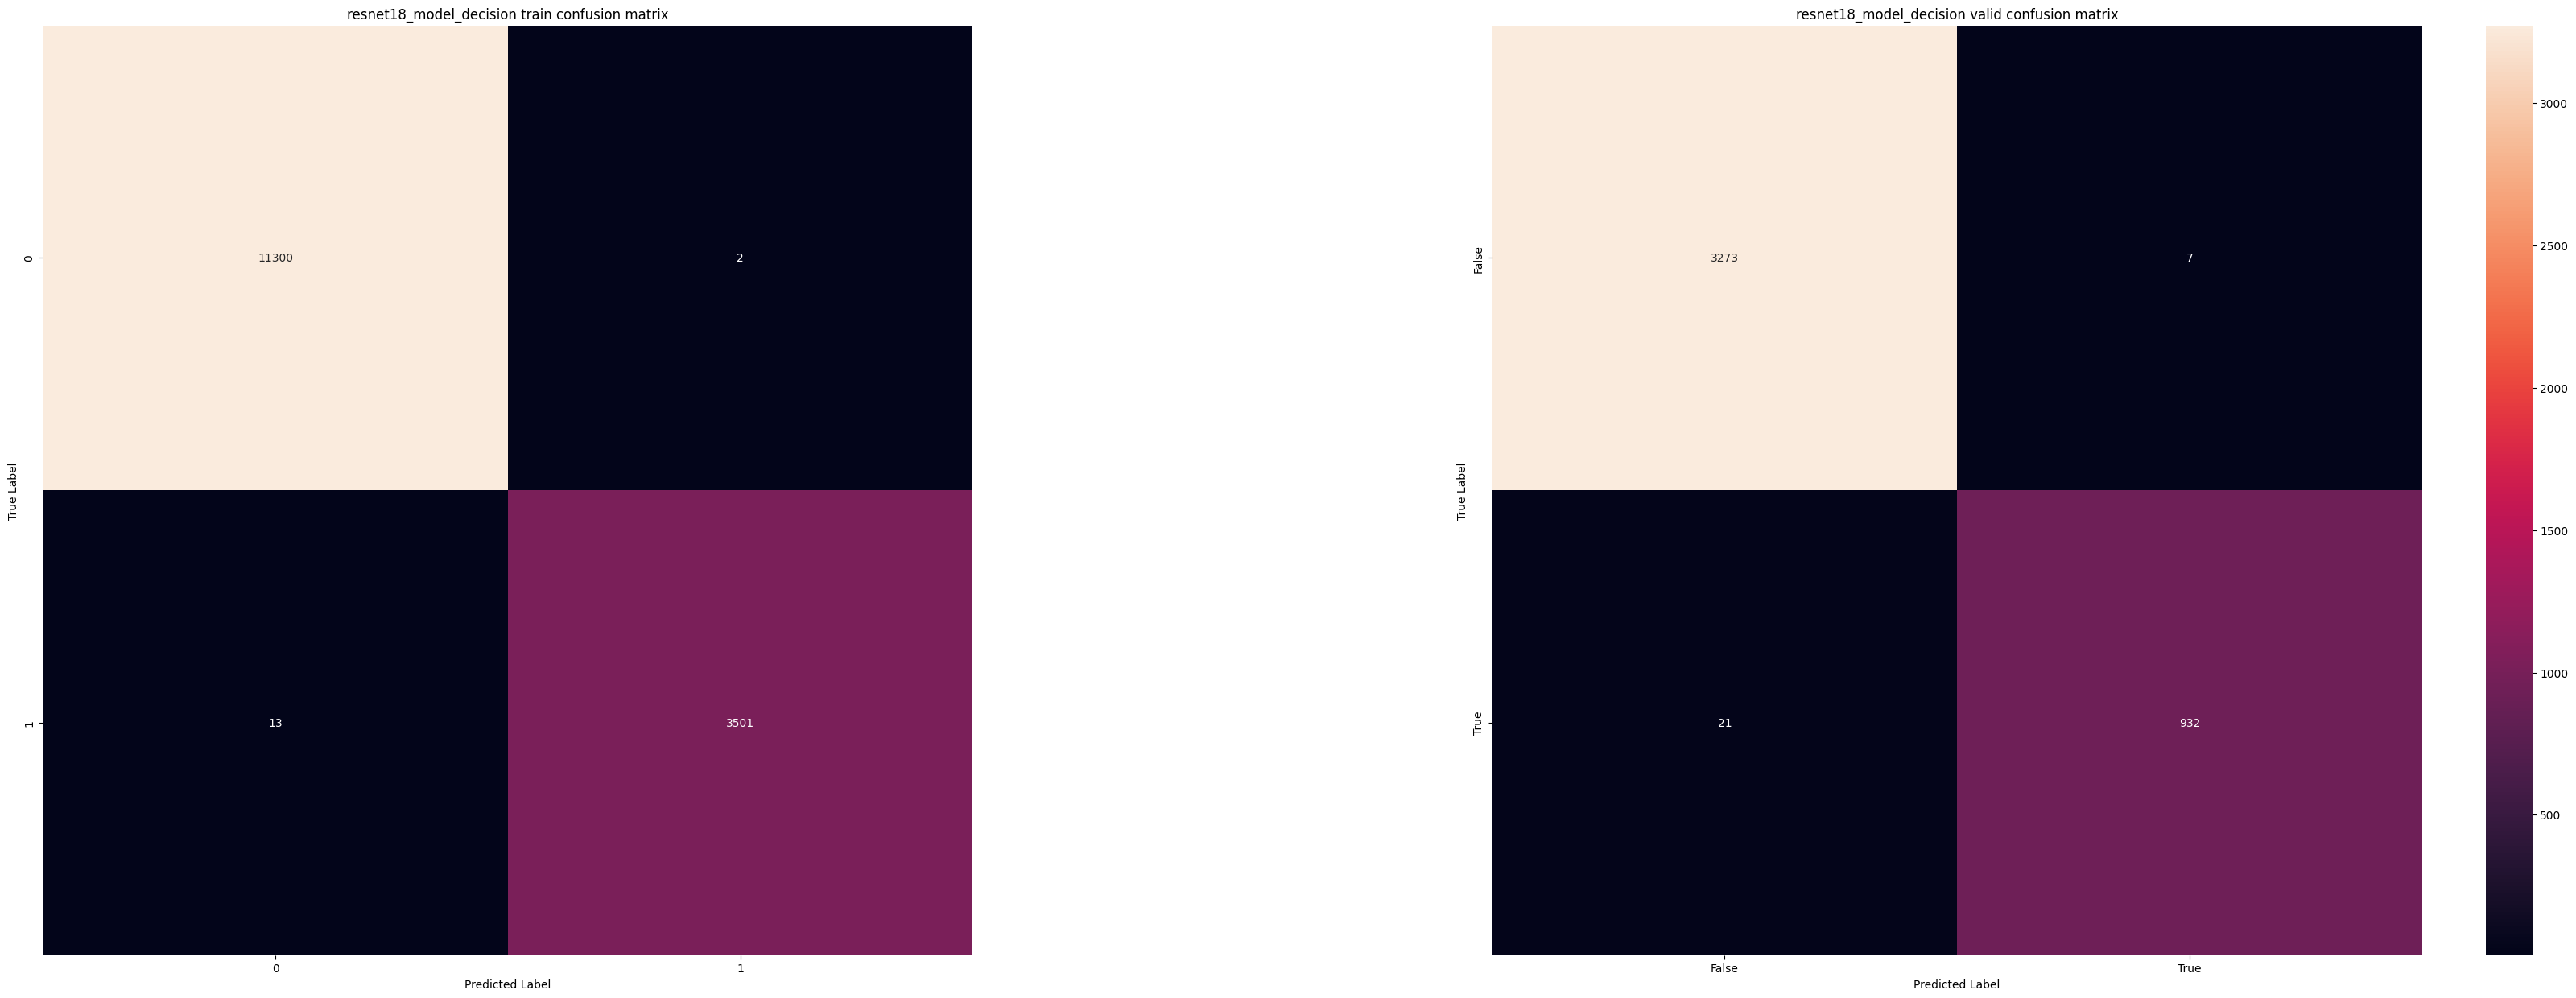

In [32]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

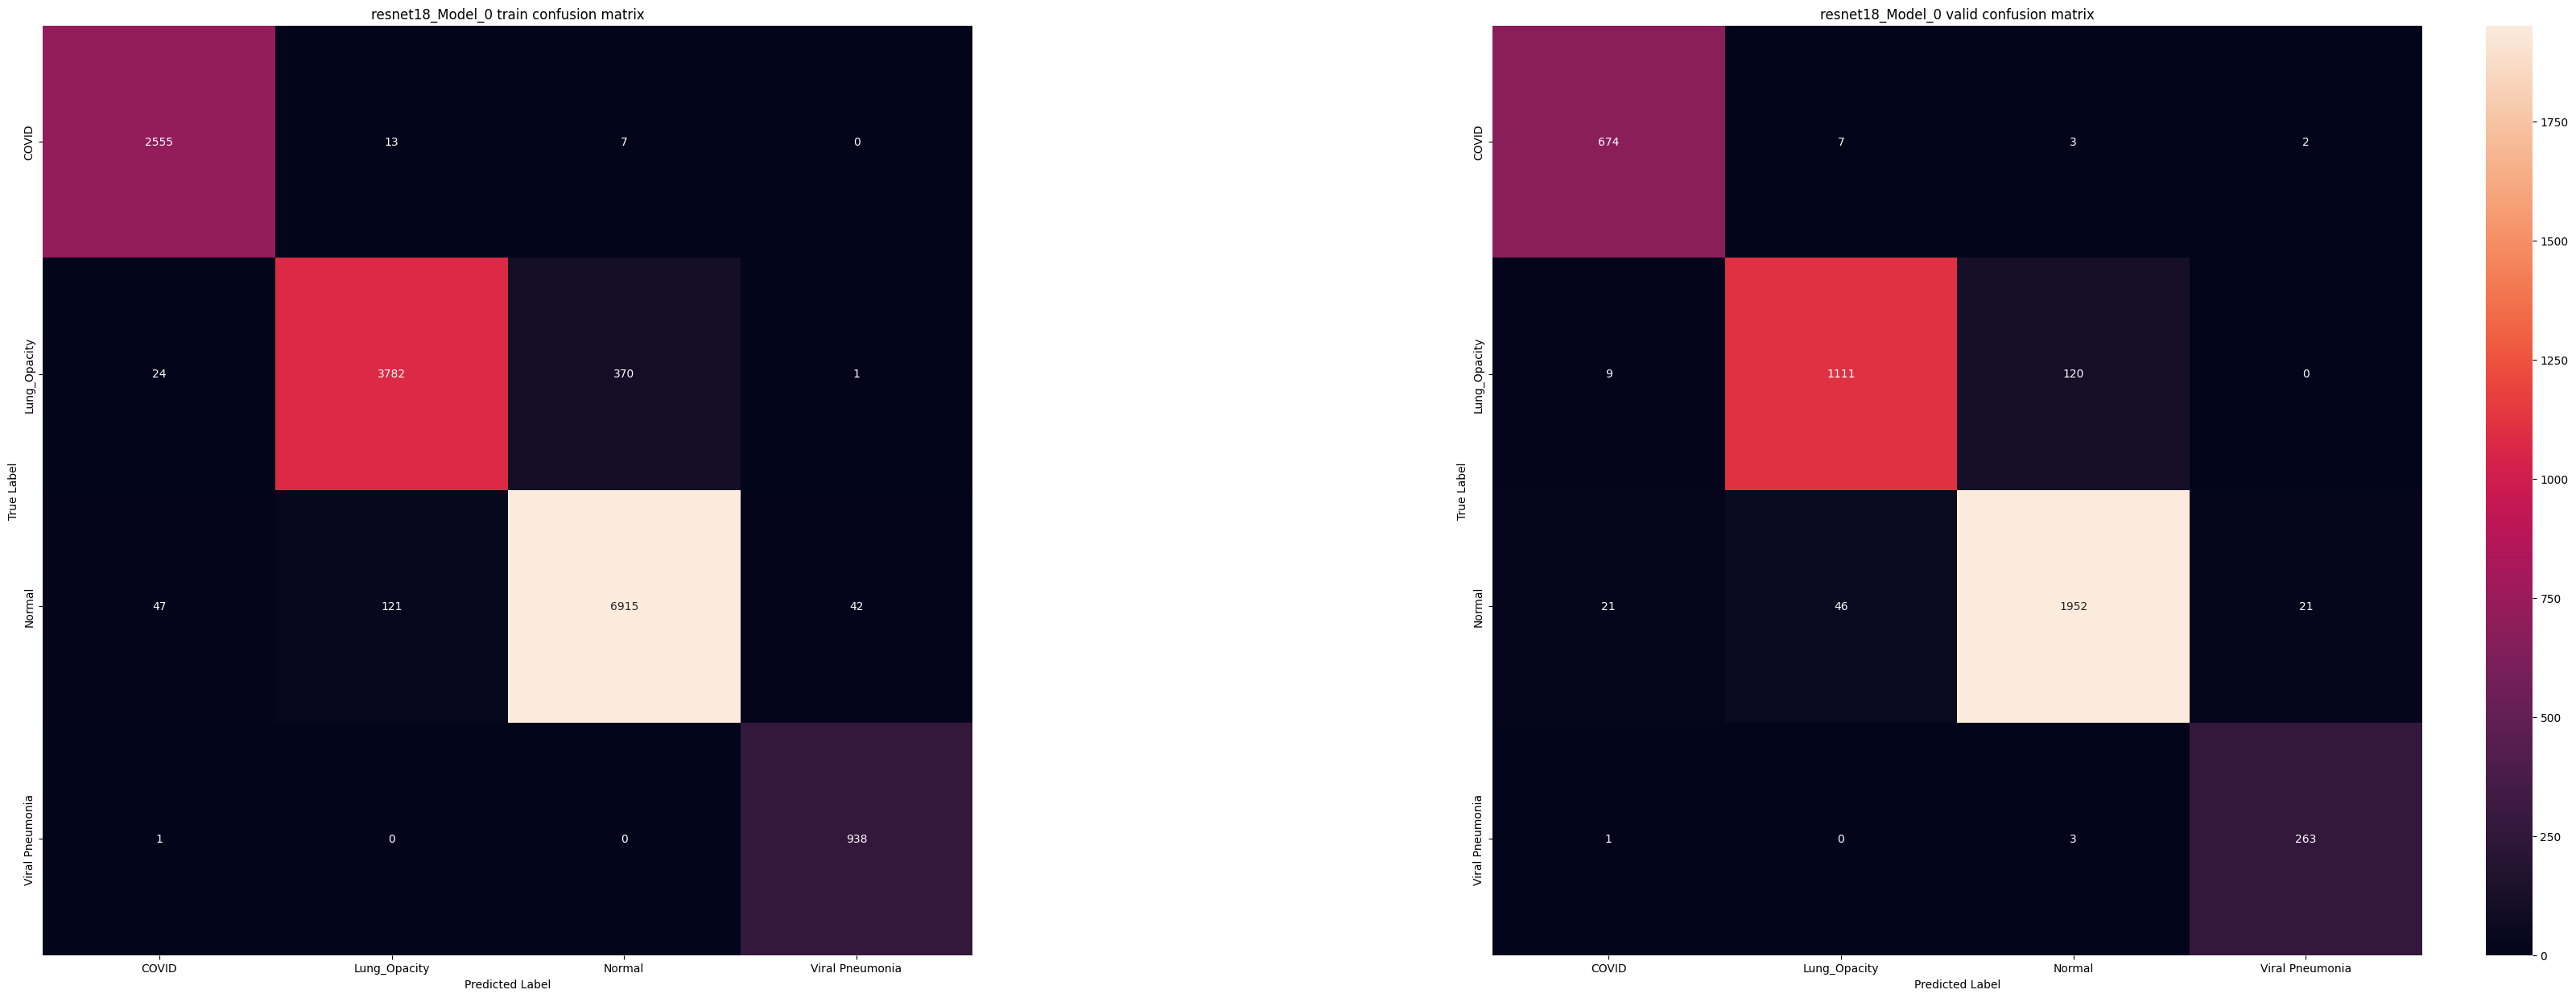

In [33]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

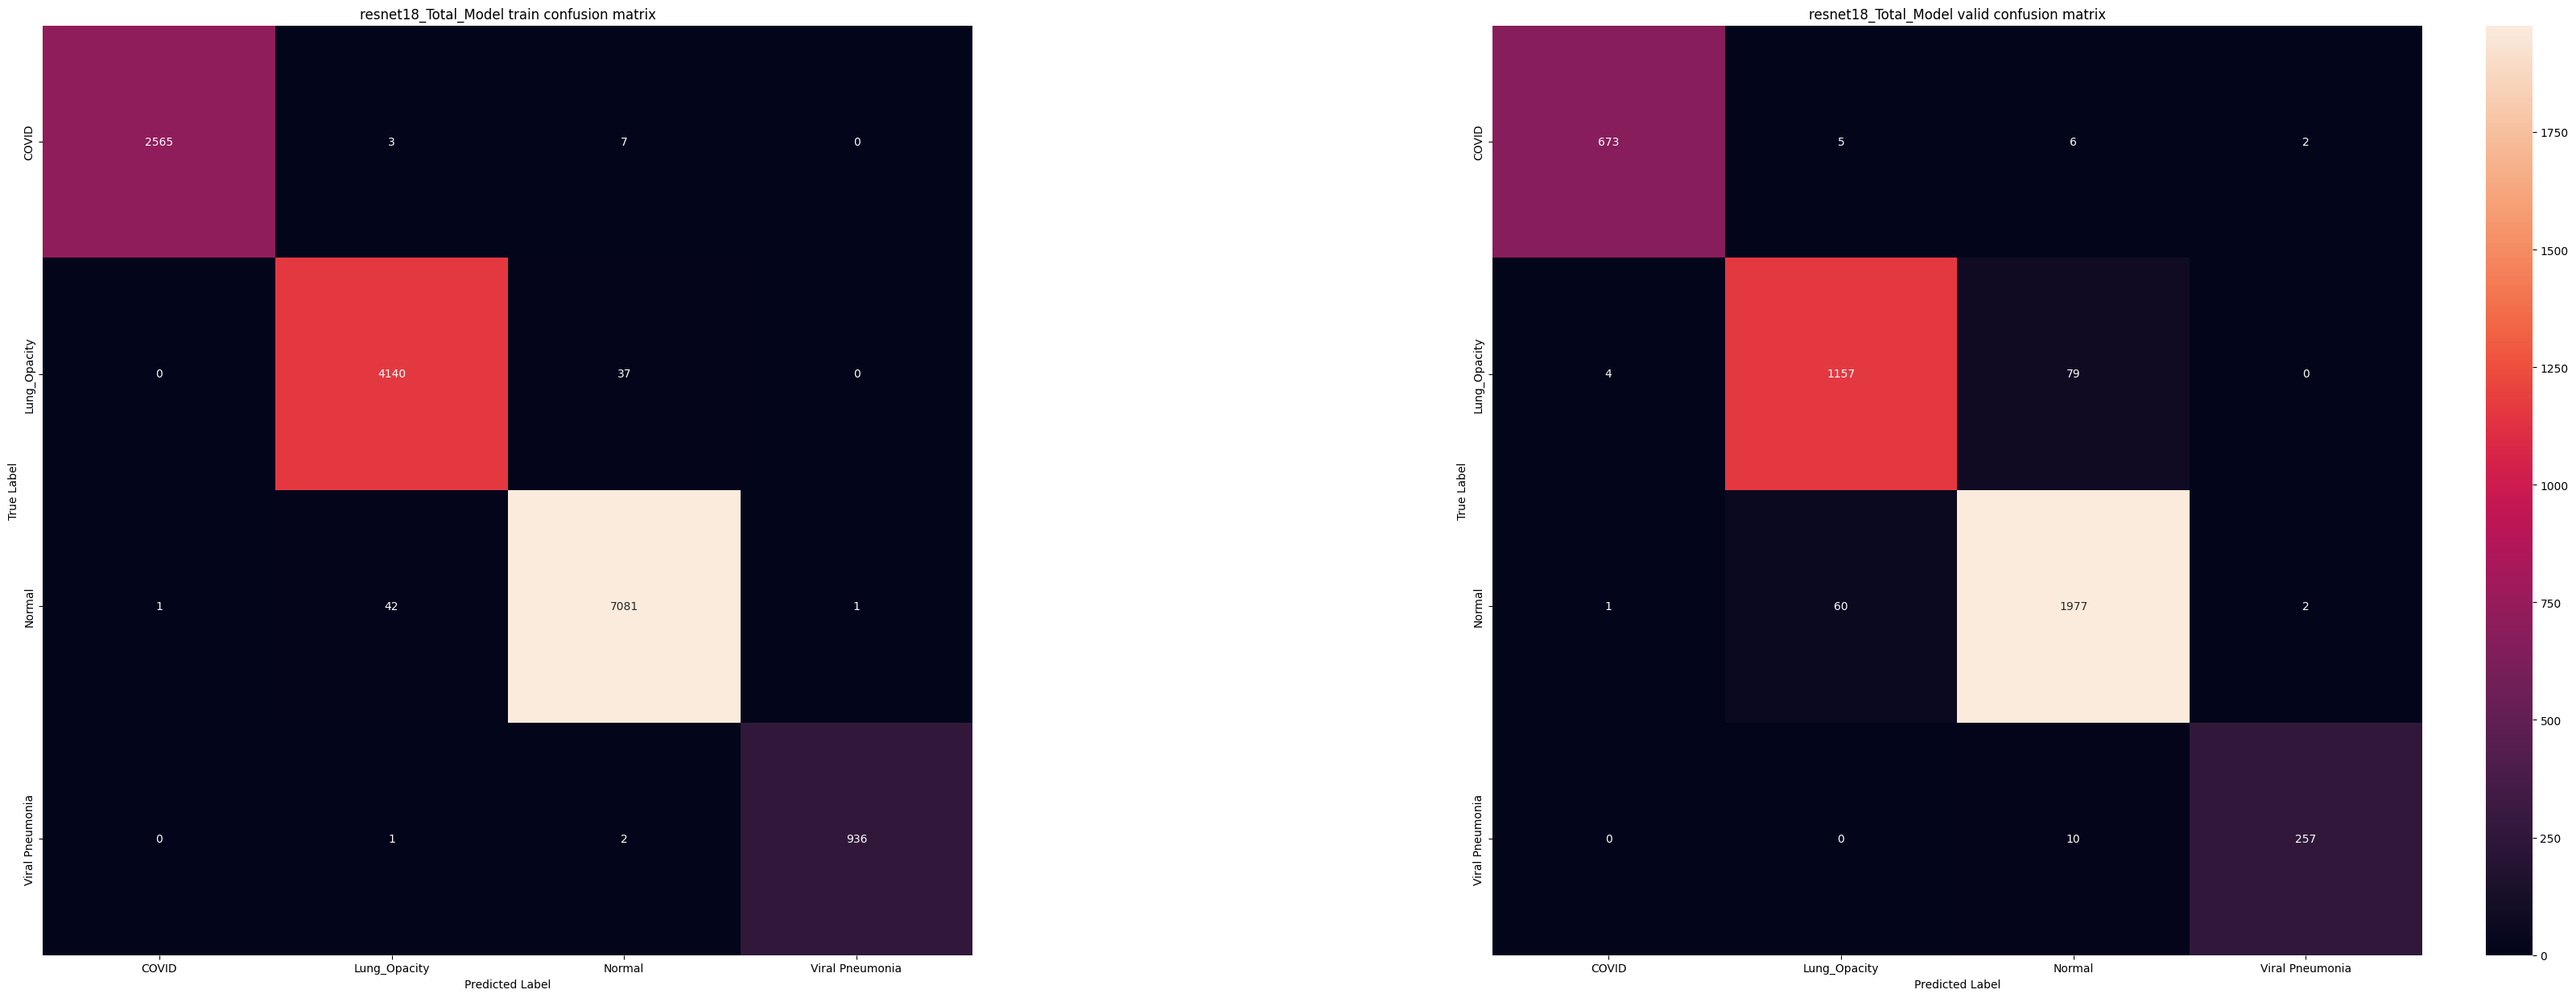

In [34]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

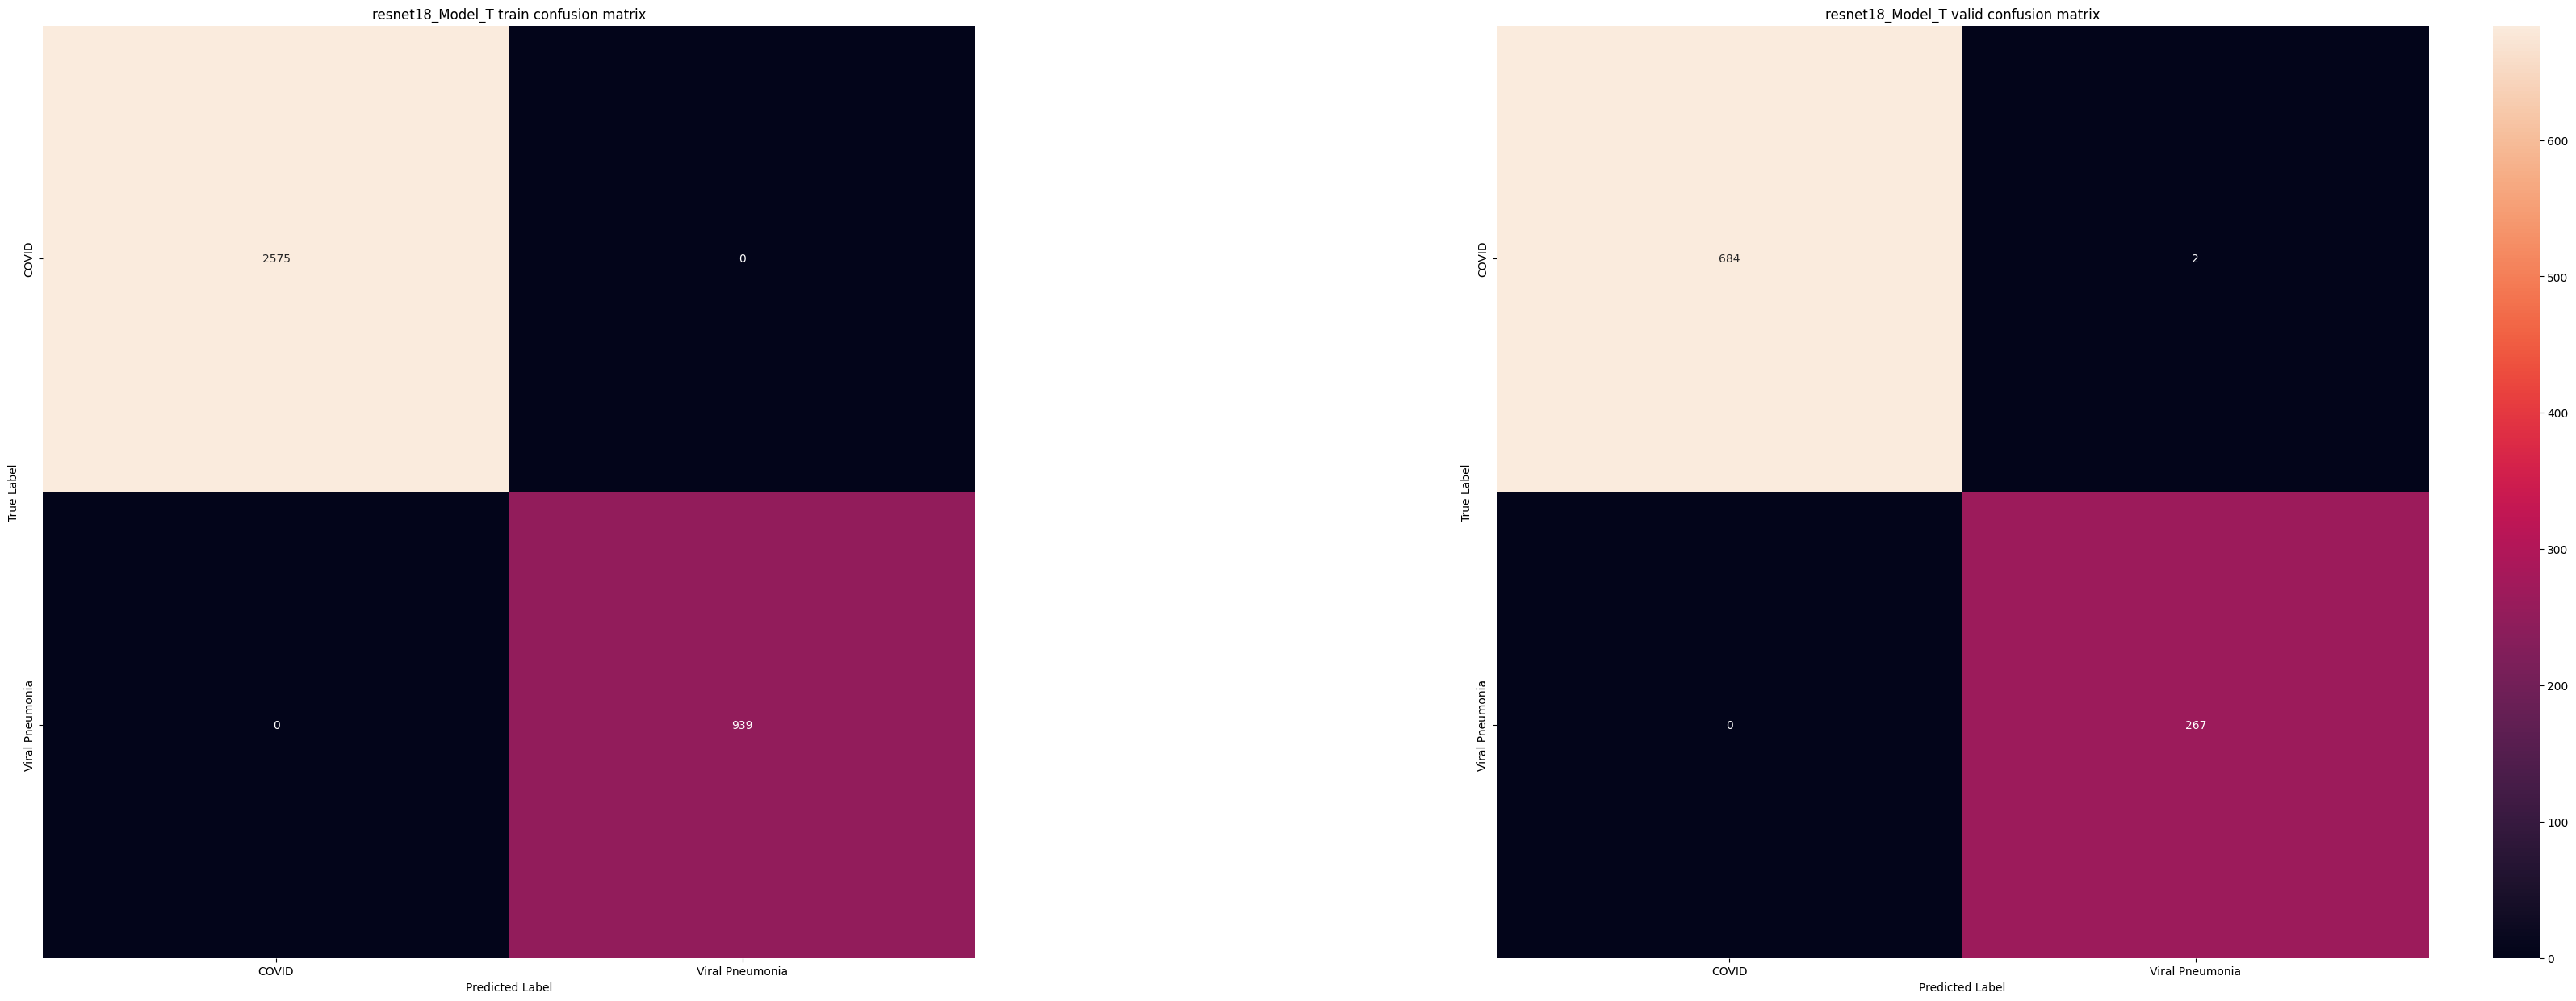

In [35]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

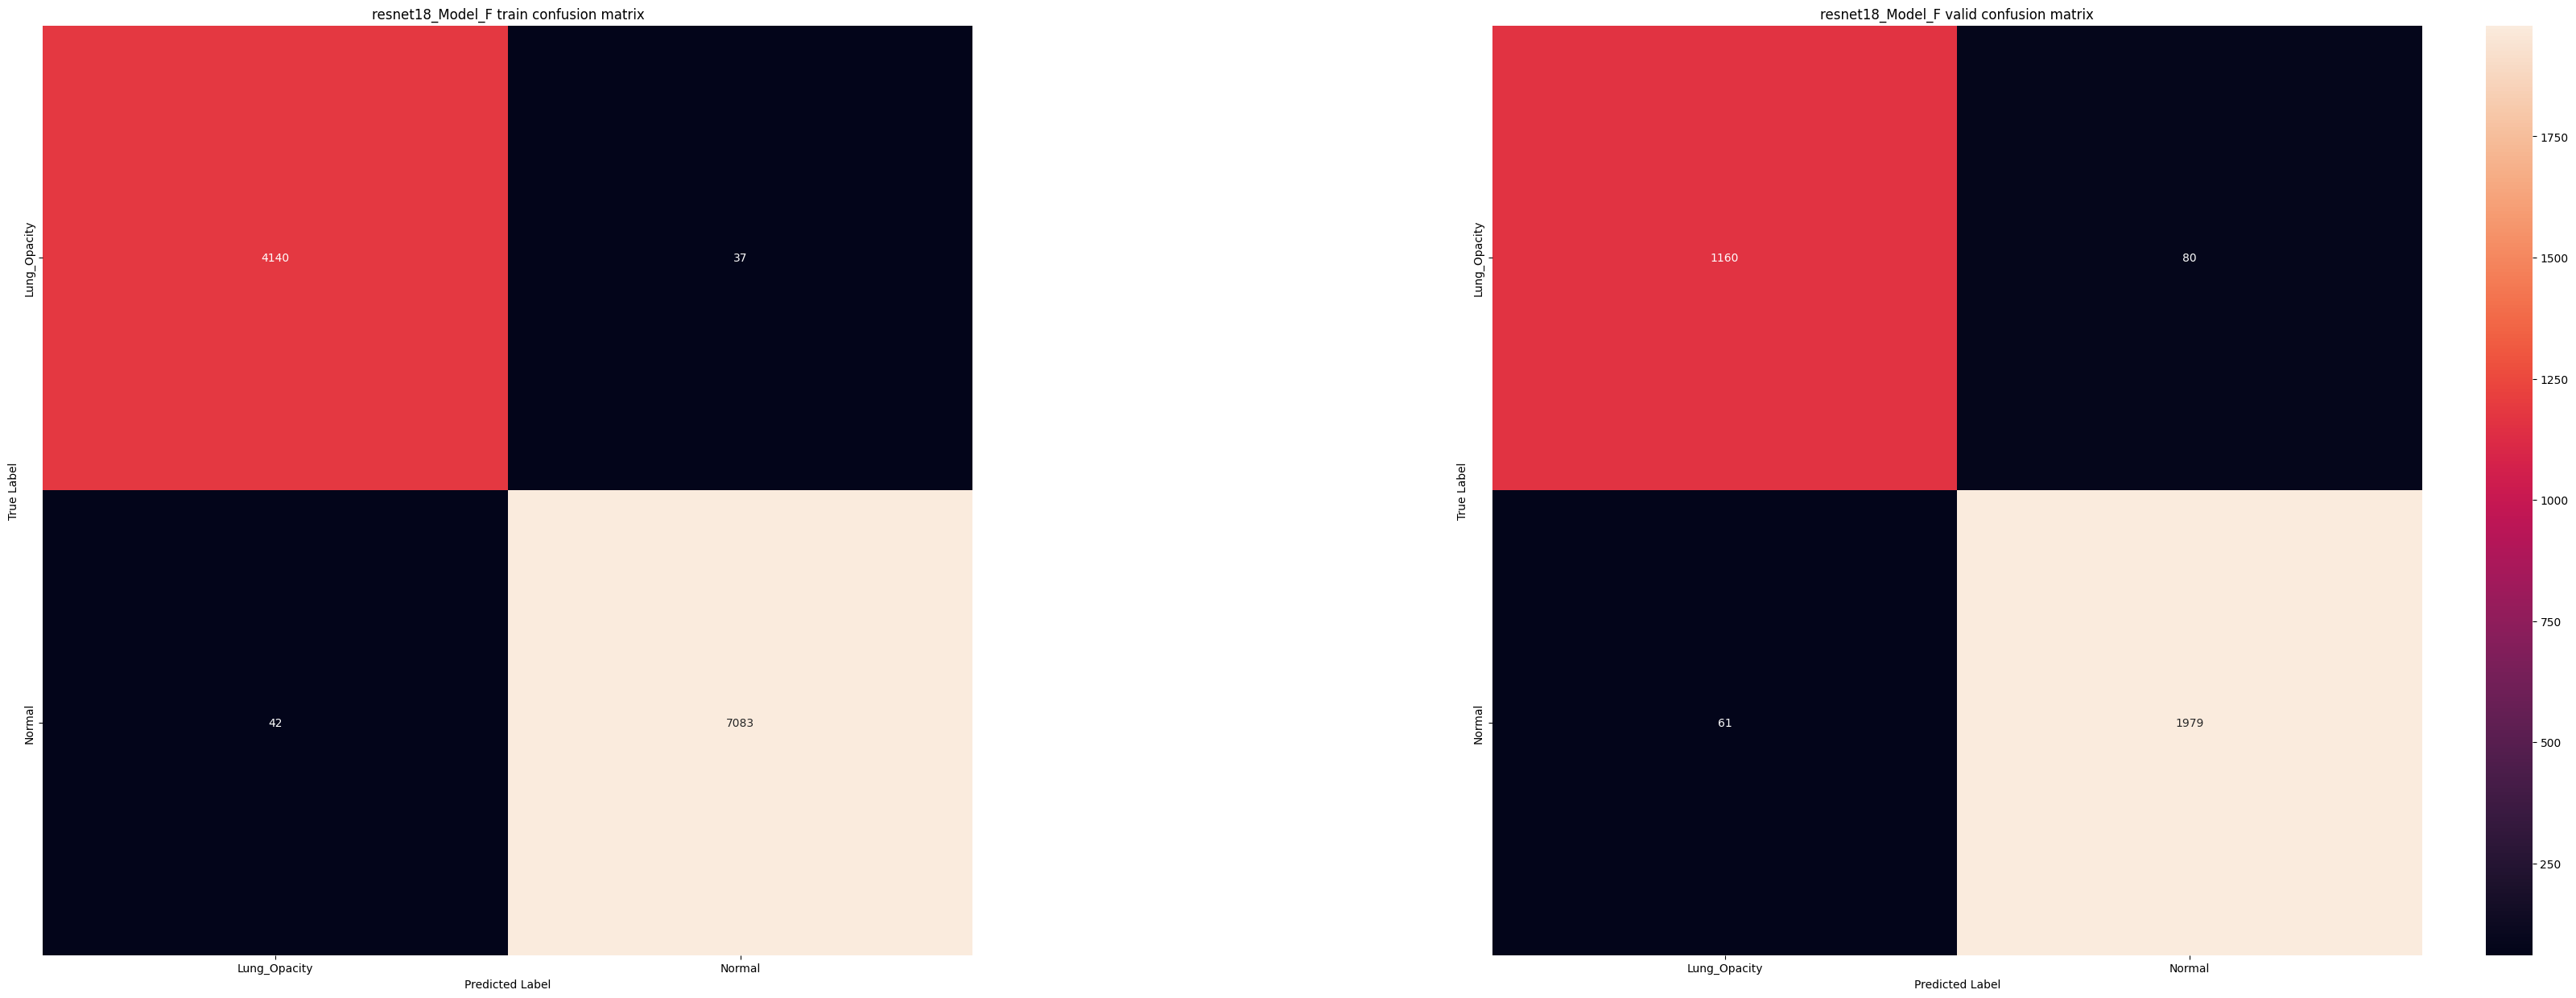

In [36]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)